In [ ]:
import pandas as pd

drug_df = pd.read_csv(r'c:\Users\richa\Desktop\Projects\FAERS Project\Data\DRUG25Q4.txt', delimiter = '$', encoding = 'latin-1')
reac_df = pd.read_csv(r'c:\Users\richa\Desktop\Projects\FAERS Project\Data\REAC25Q4.txt', delimiter = '$', encoding = 'latin-1')
demo_df = pd.read_csv(r'c:\Users\richa\Desktop\Projects\FAERS Project\Data\DEMO25Q4.txt', delimiter = '$', encoding = 'latin-1')
outc_df = pd.read_csv(r'c:\Users\richa\Desktop\Projects\FAERS Project\Data\OUTC25Q4.txt', delimiter = '$', encoding = 'latin-1')
indi_df = pd.read_csv(r'c:\Users\richa\Desktop\Projects\FAERS Project\Data\INDI25Q4.txt', delimiter = '$', encoding = 'latin-1')


C:\Users\richa\AppData\Local\Temp\ipykernel_21744\3146728080.py:5: DtypeWarning: Columns (0: to_mfr) have mixed types. Specify dtype option on import or set low_memory=False.
  demo_df = pd.read_csv('C:/Users/richa/Desktop/Projects/data/DEMO25Q4.txt', delimiter = '$', encoding = 'latin-1')


In [3]:
print(drug_df.head())

print(drug_df.shape)

print(drug_df.columns.tolist())

print(drug_df.isnull().sum())

print(drug_df.describe())

   primaryid    caseid  drug_seq role_cod  \
0  100324053  10032405         1       PS   
1  100324053  10032405         2       SS   
2  100324053  10032405         3       SS   
3  100324053  10032405         4       SS   
4  100324053  10032405         5       SS   

                                            drugname  \
0                                          CEFPROZIL   
1                PNEUMOCOCCAL VACCINE POLYVALENT NOS   
2           PNEUMOCOCCAL 13-VALENT CONJUGATE VACCINE   
3  PNEUMOCOCCAL 7-VALENT CONJUGATE VACCINE (DIPHT...   
4                                       PNEUMOVAX 23   

                                             prod_ai  val_vbm    route  \
0                                          CEFPROZIL        1  Unknown   
1                   PNEUMOCOCCAL VACCINE, POLYVALENT        1  Unknown   
2           PNEUMOCOCCAL 13-VALENT CONJUGATE VACCINE        1  Unknown   
3  PNEUMOCOCCAL 7-VALENT CONJUGATE VACCINE (DIPHT...        1  Unknown   
4                PNEUM

drug_df contains drug names, dosage, role in the event

Identifier columns:
primaryid - Unique report ID
caseid - case identifier
drug_seq - drug sequence number. one case can have multiple drugs

Drug info columns:
drugname - name of the drug reported
prod_ai - active ingredient of the drug
nda_num - FDA New Drug Application Number
lot_num - lot/batch number of the drug
exp_dt - expiration date of the drug

Role columns:
role_cod - role of the drug in the adverse event
    4 possible values
        PS = Primary Suspect - drug most likely caused the reaction
        SS = Secondary Suspect - drug may have contributed
        C = Concomitant - drug was being taken at the same time but not suspected
        I = Interacting - drug interacted with another drug

Dosage columns:
dose_amt - amount of the dose taken
dose_unit - unit of the dose. mg, ml, etc.
dose_form - form of the drug. tablet, capsule, injection, etc.
dose_freq - how often the drug was taken. daily, weekly, etc.
dose_vbm - verbatim dose as reported. raw text exactly as submitted
cum_dose_chr - cumulative dose amount
cum_dose_unit - unit for the cumulative dose

Rechallenge columns:
dechal - dechallenge. Did the reaction stop when the drug was stopped? Y or N
rechal - rechallenge. Did the reaction come back when the drug was restarted? Y or N

Validation Column:
val_vbm - validation flag for verbatim drug name
route - How the drug was administered: oral, intraveneous, trpical, etc.

focus on these columns:
'primaryid', 'caseid', 'drugname', 'role_cod', 'route', 'dose_amt', 'dose_unit', 'dose_form', 'dose_freq'

In [4]:
# Most commonly reported drugs
print(drug_df['drugname'].value_counts().head(10))

# Breakdown of drug roles
print(drug_df['role_cod'].value_counts())

# Most common administration routes
print(drug_df['route'].value_counts().head(10))

# Most common dose forms
print(drug_df['dose_form'].value_counts().head(10))

drugname
DUPIXENT         50067
ZEPBOUND         27362
MOUNJARO         26683
PREDNISONE       23806
METHOTREXATE     23332
INFLIXIMAB       21596
VEDOLIZUMAB      18702
RITUXIMAB        16036
ACETAMINOPHEN    14489
ACTEMRA          12924
Name: count, dtype: int64
role_cod
SS    687320
C     679402
PS    437206
I      11340
DN        81
Name: count, dtype: int64
route
Unknown                                  482337
Oral                                     207068
Subcutaneous                             150707
Intravenous (not otherwise specified)    102246
Intravenous use                           23443
Intravenous drip                          18104
Oral use                                  17425
Topical                                   16448
Subcutaneous use                          12464
Other                                      9659
Name: count, dtype: int64
dose_form
Tablet                                      156000
Solution for injection                      126032
Unknown    

Encountered missing administration route data which is common in voluntary reporting systems like FAERS and filtered it out to ensure accurate visualization

In [5]:
print(demo_df.head())

print(demo_df.shape)

print(demo_df.columns.tolist())

print(demo_df.isnull().sum())

print(demo_df.describe())

    primaryid    caseid  caseversion i_f_code    event_dt    mfr_dt  \
0   100324053  10032405            3        F         NaN  20251110   
1  1012809821  10128098           21        F  20140219.0  20251003   
2   101406268  10140626            8        F  20120301.0  20250929   
3   101515934  10151593            4        F         NaN  20251014   
4  1016133068  10161330           68        F         NaN  20251002   

   init_fda_dt    fda_dt rept_cod auth_num  ... age_grp sex e_sub     wt  \
0     20140320  20251120      EXP      NaN  ...     NaN   F     Y    NaN   
1     20140428  20251010      EXP      NaN  ...       A   F     Y  70.00   
2     20140429  20251007      EXP      NaN  ...       A   F     Y  77.09   
3     20140505  20251020      EXP      NaN  ...       A   F     Y    NaN   
4     20140509  20251009      EXP      NaN  ...       E   F     Y  63.00   

  wt_cod   rept_dt to_mfr occp_cod  reporter_country occr_country  
0    NaN  20251120    NaN      NaN              

demo_df is patient demographics (age, gender, country)
Identifier columns:
primaryid - unique id
caseid - case identifier
caseversion - version number of the report. Higher number = more recent update

Date Columns:
event_dt - date the adverse event happened
mfr_dt - date the manufacturer recieved the report
init_fda_dt - date the FDA first received the report
fda_dt - most recent date FDA recieved an update
rept_dt - date the report was submitted

Report info columns:
rept_cod - how the report was submitted. EXP = expedited, PER = periodic, DIR = direct
i_f_code - initial or follow-up report. I = initial, F = follow up
auth_num - authorization number
mfr_num - manufacturers report number
mfr_sndr - name of the manufacturer who sent the report
lit_ref - literature reference if report came from a published study
e_sub - whether it was electronically submitted. Y or N
to_mfr - whether FDA forwarded the report to the manufacturer. Y or N

Patient info columns:
age - patient age
age_cod - unit of the age. YR = years, MON = months, DEC = decades
age_grp - age group category. N = neonate, I = infant, C = child, A = adult, E = elderly
sex - patient sex. M = male, F = female, UNK = unknown
wt - patient weight as a number
wt_cod - unit of weight. KG = kilograms, LBS = pounds
occp_cod - Occupation of the reporter. MD = doctor, PH = pharmacist, CN = consumer, OT = other

Location columns:
reporter_country - country where the report was submitted from
occr_country - country where the adverse event actually occured

focus on these columns:
'primaryid', 'caseid', 'age', 'age_cod', 'age_grp', 'sex', 'wt', 'wt_cod', 'reporter_country', 'occr_country'

In [6]:
print(reac_df.head())

print(reac_df.shape)

print(reac_df.columns.tolist())

print(reac_df.isnull().sum())

print(reac_df.describe())

    primaryid    caseid                                     pt drug_rec_act
0   100324053  10032405                       Drug ineffective          NaN
1   100324053  10032405                        Drug resistance          NaN
2   100324053  10032405                Meningitis pneumococcal          NaN
3  1012809821  10128098                Injection site reaction          NaN
4  1012809821  10128098  General physical health deterioration          NaN
(1349105, 4)
['primaryid', 'caseid', 'pt', 'drug_rec_act']
primaryid             0
caseid                0
pt                    0
drug_rec_act    1347381
dtype: int64
          primaryid        caseid
count  1.349105e+06  1.349105e+06
mean   3.945669e+08  2.512979e+07
std    5.214957e+08  2.118364e+06
min    4.202112e+07  4.202111e+06
25%    2.574457e+08  2.542978e+07
50%    2.597816e+08  2.593639e+07
75%    2.612008e+08  2.607896e+07
max    2.168458e+10  2.623308e+07


reac_df is adverse reactions reported

primaryid - unique report ID
caseid - case identifier
pt - preferred term. Standardized medical term for the adverse reaction reported
drug_rec_act - Drug recommended action - what action was taken with the drug after the reaction

pt (preferred term) - come from standardized medical dictionary called MedDRA. This means it is consistent across all reports
    nausea
    headache
    death
    cardiac arrest
    hair lost

drug_rec_act common values:
    drug withdrawn: drug was stopped
    dose reduced: dose was lowered
    dose increased: dose was raised
    unknown: no information provided

In [7]:
# Most common adverse reactions
print(reac_df['pt'].value_counts().head(10))

# Drug recommended actions breakdown
print(reac_df['drug_rec_act'].value_counts().head(10))

# How many unique reactions exist
print(reac_df['pt'].nunique())

# How many unique drug recommended actions exist
print(reac_df['drug_rec_act'].nunique())

pt
Off label use                  27820
Drug ineffective               22367
Product dose omission issue    17519
Fatigue                        16036
Diarrhoea                      15160
Nausea                         14984
Death                          13243
Headache                       12185
Pruritus                       11689
Dyspnoea                       10902
Name: count, dtype: int64
drug_rec_act
Injection site pain    50
Diarrhoea              38
Pyrexia                31
Nausea                 31
Rash                   30
Headache               27
Dyspnoea               25
Asthenia               20
Fatigue                19
Neutropenia            18
Name: count, dtype: int64
12726
646


One case can have multiple reactions. More rows than cases

In [8]:
print(outc_df.head())

print(outc_df.shape)

print(outc_df.columns.tolist())

print(outc_df.isnull().sum())

print(outc_df.describe())

    primaryid    caseid outc_cod
0   100324053  10032405       DE
1   100324053  10032405       OT
2  1012809821  10128098       OT
3   101406268  10140626       HO
4   101406268  10140626       OT
(289721, 3)
['primaryid', 'caseid', 'outc_cod']
primaryid    0
caseid       0
outc_cod     0
dtype: int64
          primaryid        caseid
count  2.897210e+05  2.897210e+05
mean   3.072435e+08  2.550897e+07
std    3.263130e+08  1.693646e+06
min    4.202112e+07  4.202111e+06
25%    2.587868e+08  2.586141e+07
50%    2.599956e+08  2.598674e+07
75%    2.612139e+08  2.611008e+07
max    2.168458e+10  2.623308e+07


outc_df is patient outcomes (hospitalization, death, etc.)

primaryid - unique report id
caseid - case identified
outc_cod - outcome code. what happened to the patient as a result of the adverse event

outc_cod values:
DE - death
LT - life threatening
HO - hospitalization
DS - disability
CA - congenital anomaly (birth defect)
RI - reuired intervention to prevent permanent damage
OT - other serious outcome

one case can have multiple outcomes. For example, one patient can be both hospitalized and had a life threatening reaction

In [9]:
# Breakdown of all outcomes
print(outc_df['outc_cod'].value_counts())

# What percentage of cases resulted in death
total = len(outc_df)
deaths = len(outc_df[outc_df['outc_cod'] == 'DE'])
print(f"Death percentage: {round(deaths/total * 100, 2)}%")

outc_cod
OT    161458
HO     80556
DE     26291
LT     13126
DS      6065
CA      1371
RI       854
Name: count, dtype: int64
Death percentage: 9.07%


In [10]:
print(indi_df.head())

print(indi_df.shape)

print(indi_df.columns.tolist())

print(indi_df.isnull().sum())

print(indi_df.describe())

   primaryid    caseid  indi_drug_seq                 indi_pt
0  100324053  10032405              1  Antibiotic prophylaxis
1  100324053  10032405              2            Immunisation
2  100324053  10032405              3            Immunisation
3  100324053  10032405              4            Immunisation
4  100324053  10032405              5            Immunisation
(1168789, 4)
['primaryid', 'caseid', 'indi_drug_seq', 'indi_pt']
primaryid        0
caseid           0
indi_drug_seq    0
indi_pt          0
dtype: int64
          primaryid        caseid  indi_drug_seq
count  1.168789e+06  1.168789e+06   1.168789e+06
mean   3.545004e+08  2.524990e+07   2.285908e+01
std    5.692275e+08  2.029085e+06   7.993567e+01
min    4.202112e+07  4.202111e+06   1.000000e+00
25%    2.579428e+08  2.559934e+07   1.000000e+00
50%    2.598466e+08  2.596026e+07   3.000000e+00
75%    2.611816e+08  2.609260e+07   1.100000e+01
max    2.168458e+10  2.623308e+07   1.854000e+03


indi_df tells why the patient was taking the drug

primaryid - unique report id
caseid - caseidentifier
indi_drug_seq - links to drug_seq in the drug file. Matches the indication to the specific drug it was prescribed for
    drug_df['drug_seq'] - drug sequence number. one case can have multiple drugs
        How they connect:
            drug_df has drug_seq = 1 and the drugname = 'Humira'
            indi_df has indi_drug_seq = 1 and indi_pt = 'Rheumatoid Arthritis'
                Humira was being taken for rheumatoid arthritis
indi_pt - the medical condition the drug was being taken for. Similar to the pt column in reactions but for the indiciation
    reac_df['pt'] - preferred term. Standardized medical term for the adverse reaction reported
    Commons values
        Rheumatoid Arthritis
        Cnacner
        Diabetes
        Hypertension
        Product used for unknown indication

In [11]:
# Most common conditions drugs were prescribed for
print(indi_df['indi_pt'].value_counts().head(10))

# How many unique indications exist
print(indi_df['indi_pt'].nunique())

indi_pt
Product used for unknown indication    470934
Rheumatoid arthritis                    63817
Dermatitis atopic                       19434
Crohn's disease                         13656
Weight control                          13121
Type 2 diabetes mellitus                12751
Asthma                                  12400
Plasma cell myeloma                     12262
Psoriasis                               12164
Hypertension                            11070
Name: count, dtype: int64
6921


How the 5 files connect together

DEMO (patient info)
        ↓
    primaryid
   ↙         ↘
DRUG          REAC
(drug info)   (reactions)
   ↓               ↓
drug_seq        primaryid
   ↓
 INDI              OUTC
(indication)   (outcomes)

drug_df: what drug was taken?
indi_df: why was the drug taken?
reac_df: what reaction did they have?
outc_df: what happened to the patient?
demo_df: who was the patient?

In [12]:
# Check all files loaded correctly
print("DRUG:", drug_df.shape)
print("REAC:", reac_df.shape)
print("OUTC:", outc_df.shape)
print("INDI:", indi_df.shape)
print("DEMO:", demo_df.shape)

# Strip any extra spaces from column names
drug_df.columns = drug_df.columns.str.strip().str.lower()
reac_df.columns = reac_df.columns.str.strip().str.lower()
outc_df.columns = outc_df.columns.str.strip().str.lower()
indi_df.columns = indi_df.columns.str.strip().str.lower()
demo_df.columns = demo_df.columns.str.strip().str.lower()

DRUG: (1815349, 20)
REAC: (1349105, 4)
OUTC: (289721, 3)
INDI: (1168789, 4)
DEMO: (385288, 25)


In [13]:
# merge drug_df with reac_df
df_merged = drug_df.merge(reac_df, on='primaryid', how='left')

# add outc_df
df_merged = df_merged.merge(outc_df, on='primaryid', how='left')

# add indi_df/indi_clean. needs both primaryid and drug_seq to match correctly. Only bringing in columns that are actually needed from indi_df
df_merged = df_merged.merge(indi_df[['primaryid', 'indi_drug_seq', 'indi_pt']],
                                left_on=['primaryid', 'drug_seq'],
                                right_on=['primaryid', 'indi_drug_seq'],
                                how='left')

# add demo_df
df_merged = df_merged.merge(demo_df[['primaryid', 'age', 'age_grp', 'sex', 'reporter_country', 'occr_country']],
                                on='primaryid',
                                how='left')

print("Final merged dataframe:", df_merged.shape)
print(df_merged.head())

Final merged dataframe: (94441457, 32)
   primaryid  caseid_x  drug_seq role_cod   drugname    prod_ai  val_vbm  \
0  100324053  10032405         1       PS  CEFPROZIL  CEFPROZIL        1   
1  100324053  10032405         1       PS  CEFPROZIL  CEFPROZIL        1   
2  100324053  10032405         1       PS  CEFPROZIL  CEFPROZIL        1   
3  100324053  10032405         1       PS  CEFPROZIL  CEFPROZIL        1   
4  100324053  10032405         1       PS  CEFPROZIL  CEFPROZIL        1   

     route                  dose_vbm  cum_dose_chr  ... drug_rec_act  \
0  Unknown  UNK UNK,Two Times a Day,           NaN  ...          NaN   
1  Unknown  UNK UNK,Two Times a Day,           NaN  ...          NaN   
2  Unknown  UNK UNK,Two Times a Day,           NaN  ...          NaN   
3  Unknown  UNK UNK,Two Times a Day,           NaN  ...          NaN   
4  Unknown  UNK UNK,Two Times a Day,           NaN  ...          NaN   

       caseid outc_cod indi_drug_seq                 indi_pt  age  age_

In [14]:
# Overview of final merged dataframe
print(df_merged.shape)
print(df_merged.columns.tolist())
print(df_merged.isnull().sum())
print(df_merged.head(10))

(94441457, 32)
['primaryid', 'caseid_x', 'drug_seq', 'role_cod', 'drugname', 'prod_ai', 'val_vbm', 'route', 'dose_vbm', 'cum_dose_chr', 'cum_dose_unit', 'dechal', 'rechal', 'lot_num', 'exp_dt', 'nda_num', 'dose_amt', 'dose_unit', 'dose_form', 'dose_freq', 'caseid_y', 'pt', 'drug_rec_act', 'caseid', 'outc_cod', 'indi_drug_seq', 'indi_pt', 'age', 'age_grp', 'sex', 'reporter_country', 'occr_country']
primaryid                  0
caseid_x                   0
drug_seq                   0
role_cod                   0
drugname                   0
prod_ai               605675
val_vbm                    0
route               30124243
dose_vbm            27340897
cum_dose_chr        93984944
cum_dose_unit       93984944
dechal              14667422
rechal              88818610
lot_num             76926421
exp_dt              94431657
nda_num             85666241
dose_amt            51742084
dose_unit           51742084
dose_form           58642925
dose_freq           77522265
caseid_y           

In [15]:
# Filter to primary suspect drugs only
df_primary = df_merged[df_merged['role_cod'] == 'PS']
print("Primary suspect drugs only:", df_primary.shape)

Primary suspect drugs only: (3567561, 32)


In [16]:
# Top 10 most reported drugs
print(df_primary['drugname'].value_counts().head(10))

# Top 10 most common reactions
print(df_primary['pt'].value_counts().head(10))

# Outcome breakdown
print(df_primary['outc_cod'].value_counts())

# Top reporter countries
print(df_primary['reporter_country'].value_counts().head(10))

drugname
VEDOLIZUMAB                                               183544
HUMAN IMMUNOGLOBULIN G                                    176135
DUPIXENT                                                  111153
TEDUGLUTIDE                                               108679
ORENCIA                                                    85920
CIMZIA                                                     80321
HUMAN IMMUNOGLOBULIN G\HYALURONIDASE RECOMBINANT HUMAN     67847
FOSAMAX                                                    62357
IDURSULFASE                                                62150
CELECOXIB                                                  51742
Name: count, dtype: int64
pt
Off label use                  61877
Fatigue                        40832
Drug ineffective               40487
Diarrhoea                      39121
Product dose omission issue    34545
Nausea                         34073
Headache                       29909
Dyspnoea                       28531
Pain            

Pt is showing off label use, but that should be in indi_pt column as off label use is an indication, not a reaction. Pt should contain medical reactions like nausea, headache, death, etc.
    off label use means that a drug was being taken for a condition that the FDA did not officially approve it for
        For example: ozempic was FDA approved for diabeetes but widely used off label for weight loss
                     gabapentin was approved for seizuers but often prescribed off label for anxiety or back pain

What this means is that FAERS data has data quality issues where reportes accidently put indication information into the reaction field. This is apparently known of the FAERS dataset.

In [17]:
# See top 20 to get a better picture
print(df_primary['pt'].value_counts().head(20))

pt
Off label use                                       61877
Fatigue                                             40832
Drug ineffective                                    40487
Diarrhoea                                           39121
Product dose omission issue                         34545
Nausea                                              34073
Headache                                            29909
Dyspnoea                                            28531
Pain                                                27707
Vomiting                                            26393
Pneumonia                                           24261
Malaise                                             24172
Arthralgia                                          23986
Death                                               23625
Pyrexia                                             23238
Inappropriate schedule of product administration    22880
Dizziness                                           21001
Rash       

May be worth filtering out off label use for cleaner analysis

omitting off label use, fatigue is #1
Drug ineffective is very high on the list
death is a significant one
product dose omission issue and inappropriate schedule of product administration suggests medication errors are common

In [18]:
# Filter out off label use
reac_clean = df_primary[df_primary['pt'] != 'Off label use']

# Now check top 20 real reactions
print(reac_clean['pt'].value_counts().head(20))

pt
Fatigue                                             40832
Drug ineffective                                    40487
Diarrhoea                                           39121
Product dose omission issue                         34545
Nausea                                              34073
Headache                                            29909
Dyspnoea                                            28531
Pain                                                27707
Vomiting                                            26393
Pneumonia                                           24261
Malaise                                             24172
Arthralgia                                          23986
Death                                               23625
Pyrexia                                             23238
Inappropriate schedule of product administration    22880
Dizziness                                           21001
Rash                                                20699
Condition a

Next steps is outcomes analysis, visualizations, exporting, and dashboard building

outcome analysis:

In [22]:
# Count of each outcome code
print(df_primary['outc_cod'].value_counts())

# with percentages
outcome_pct = df_primary ['outc_cod'].value_counts(normalize=True) * 100
print(outcome_pct.round(2))

outc_cod
OT    1488118
HO     886967
LT     231478
DE     221199
DS     198089
CA      85468
RI       9865
Name: count, dtype: int64
outc_cod
OT    47.68
HO    28.42
LT     7.42
DE     7.09
DS     6.35
CA     2.74
RI     0.32
Name: proportion, dtype: float64


In [24]:
# readable codes
outcome_code = {
    'DE': 'Death',
    'LT': 'Life Threatening',
    'HO': 'Hospitalization',
    'DS': 'Disability',
    'CA': 'Congenital Anomaly',
    'RI': 'Required Intervention',
    'OT': 'Other Serious Outcome'
}

# Apply mapping
df_primary['outcome_code'] = df_primary['outc_cod'].map(outcome_code)

# check
print(df_primary['outcome_code'].value_counts())

outcome_code
Other Serious Outcome    1488118
Hospitalization           886967
Life Threatening          231478
Death                     221199
Disability                198089
Congenital Anomaly         85468
Required Intervention       9865
Name: count, dtype: int64


In [31]:
# outcome analyses

# which drugs have the most death reports
drug_death = df_primary[df_primary['outc_cod'] == 'DE']['drugname'].value_counts().head(10)
print(f"Top 10 drugs associated with death: {drug_death}")

# which drugs have the most hospitalization reports
drug_hosp = df_primary[df_primary['outc_cod'] == 'HO']['drugname'].value_counts().head(10)
print(f"Top 10 drugs associated with hospitalization: {drug_hosp}")


# which drugs have the most life threatening reports
drug_lt = df_primary[df_primary['outc_cod'] == 'LT']['drugname'].value_counts().head(10)
print(f"Top 10 drugs associated with life threatening outcomes: {drug_lt}")

Top 10 drugs associated with death: drugname
CIMZIA          15058
FOSAMAX         10129
CELECOXIB        9702
ACTEMRA          8492
ZOCOR            7309
CELEBREX         6723
METHOTREXATE     6455
ALBUTEROL        6086
RITUXIMAB        6012
ADALIMUMAB       4335
Name: count, dtype: int64
Top 10 drugs associated with hospitalization: drugname
HUMAN IMMUNOGLOBULIN G                                    65161
TEDUGLUTIDE                                               49468
VEDOLIZUMAB                                               46799
HUMAN IMMUNOGLOBULIN G\HYALURONIDASE RECOMBINANT HUMAN    26323
IDURSULFASE                                               25361
ORENCIA                                                   20074
FENFLURAMINE                                              16159
CIMZIA                                                    14942
ICATIBANT                                                 11546
FOSAMAX                                                   10929
Name: count, d

# quick observations
Celecoxib, Methotrexate, Celebrex is top 10 in death and Life threatening Outcomes - could be overlap.
Cimzia is in all three, could also be overlap as someone could be have a life threatening outcome, sent to the hospital, and death is involved

In [38]:
# reactions most common with death
reaction_death = df_primary[df_primary['outc_cod'] == 'DE']['pt'].value_counts().head()
print(f"Top 10 reactions associated with death: {reaction_death}")

# since death is an outcome, remove death and count top 10 aside from death
df_temp = df_primary[df_primary['pt'] != 'Death']
reaction_death = df_temp[df_temp['outc_cod'] == 'DE']['pt'].value_counts().head()
print(f"Top 10 reactions associated with death: {reaction_death}")

reaction_hosp = df_primary[df_primary['outc_cod'] == 'HO']['pt'].value_counts().head()
print(f"Top 10 reactions associated with hospitalization: {reaction_hosp}")

Top 10 reactions associated with death: pt
Death                                    14305
Off label use                             3227
Drug ineffective                          1936
Pneumonia                                 1897
General physical health deterioration     1561
Name: count, dtype: int64
Top 10 reactions associated with death: pt
Off label use                            3227
Drug ineffective                         1936
Pneumonia                                1897
General physical health deterioration    1561
Pyrexia                                  1539
Name: count, dtype: int64
Top 10 reactions associated with hospitalization: pt
Off label use    12183
Diarrhoea        10430
Fatigue           9298
Nausea            8677
Pneumonia         8326
Name: count, dtype: int64


In [79]:
# outcome by gender
print(df_primary.groupby(['sex']).size())
outcome_gender = df_primary.groupby(['sex', 'outcome_code']).size().reset_index(name='count')
outcome_gender_sorted = outcome_gender.sort_values(by=['sex', 'count'], ascending=[True,False], inplace=True)
print(outcome_gender)

sex
F    2093477
M     990652
dtype: int64
   sex           outcome_code   count
5    F  Other Serious Outcome  857417
3    F        Hospitalization  527731
4    F       Life Threatening  151118
2    F             Disability  138217
1    F                  Death  123606
0    F     Congenital Anomaly   57802
6    F  Required Intervention    7524
12   M  Other Serious Outcome  439529
10   M        Hospitalization  266499
8    M                  Death   60513
11   M       Life Threatening   50218
9    M             Disability   34359
7    M     Congenital Anomaly   18810
13   M  Required Intervention    2189


## Gender Column Note
The sex column contains no missing or unknown values in the dataset. Makes gender analysis reliable without additional cleaning

In [53]:
# map age group codes
age_codes = {
    'N': 'Neonate',
    'I': 'Infant',
    'C': 'Child',
    'A': 'Adult',
    'E': 'Elderly',
    'U': 'Unknown'
}

df_primary['age_code'] = df_primary['age_grp'].map(age_codes)

# outcome by age group
outcome_age = df_primary.groupby(['age_code']).size().reset_index(name='count')
print(outcome_age)


  age_code   count
0    Adult  536685
1    Child   28797
2  Elderly  294624
3   Infant    5607
4  Neonate    4159


Order:
    Adult
    Elderly
    Child
    Infant
    Neonate

In [56]:
# Categorize into serious vs other (non serious)
outcome_serious = ['DE', 'LT', 'HO', 'DS', 'CA', 'RI']

# count
df_primary['is_serious'] = df_primary['outc_cod'].isin(outcome_serious)
print(df_primary['is_serious'].value_counts())

# percentage
serious_pct = df_primary['is_serious'].mean() * 100
print(f"Percentage of serious outcomes: {serious_pct.round(2)}%")

is_serious
False    1934495
True     1633066
Name: count, dtype: int64
Percentage of serious outcomes: 45.78%


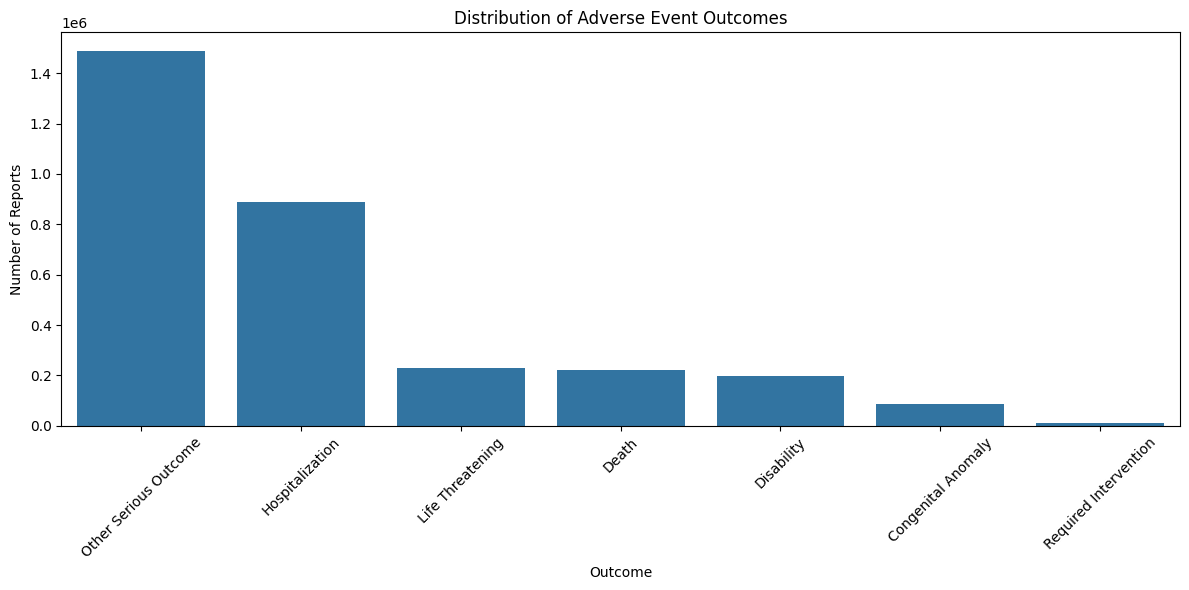

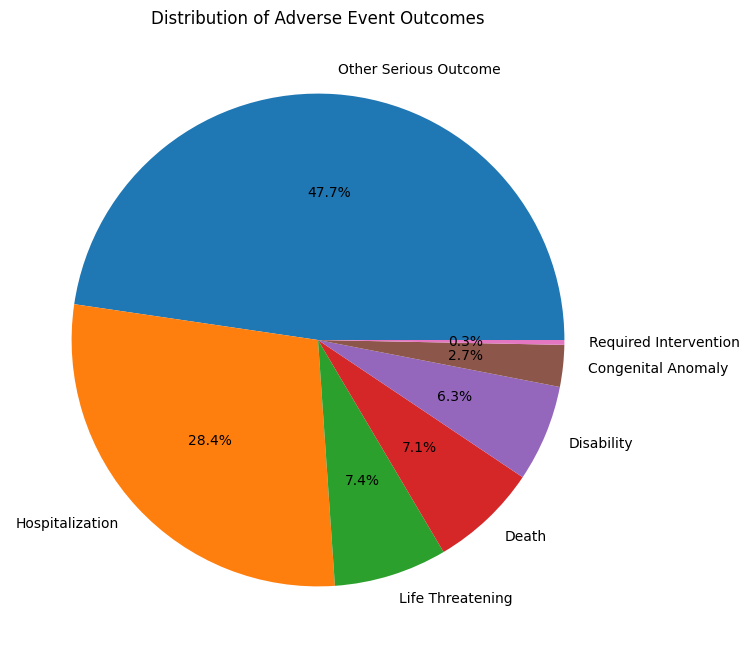

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# bar chart
outcome_counts = df_primary['outcome_code'].value_counts()

plt.figure(figsize = (12, 6))
sns.barplot(x = outcome_counts.index, y=outcome_counts.values)
plt.title('Distribution of Adverse Event Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Number of Reports')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# pie chart
plt.figure(figsize=(10, 8))
plt.pie(outcome_counts.values,
            labels = outcome_counts.index,
            autopct = '%1.1f%%')
plt.title('Distribution of Adverse Event Outcomes')
plt.show()

In [92]:
import os

os.makedirs(r'C:\Users\richa\Desktop\Projects\output', exist_ok=True)

# export outcome summary
outcome_summary = df_primary.groupby(['drugname', 'outcome_code']).size().reset_index(name='count')
outcome_summary.to_csv(r'C:\Users\richa\Desktop\Projects\output\outcome_summary.csv', index=False)

# export gender summary
gender_summary = df_primary.groupby(['sex', 'outcome_code']).size().reset_index(name='count')
gender_summary.to_csv(r'C:\Users\richa\Desktop\Projects\output\gender_summary.csv', index=False)


# export age group outcome summary
age_summary = df_primary.groupby(['age_code', 'outcome_code']).size().reset_index(name='count')
age_summary.to_csv(r'C:\Users\richa\Desktop\Projects\output\age_summary.csv', index=False)